In [1]:
import pandas as pd 
import os
import sys
sys.path.append('/home/spankaew/Git/Git_Curie/AstroLogics/src/')
import astrologics as ast
from astrologics import logic_generator
import seaborn as sns
import matplotlib.pyplot as plt
os.chdir('/home/spankaew/Git/Git_Curie/AstroLogics/')

In [2]:
import mpbn

bnet_model = '/home/spankaew/Git/Git_Curie/AstroLogics/models/synthetic_random_diff.bnet'
if __name__ == "__main__":
    bn = mpbn.MPBooleanNetwork(bnet_model)
    print("input BN has", len(list(bn.fixedpoints())), "fixed points")

    print("-"*10, "no constraints:")
    solution_1 = logic_generator.bonesis_ensemble_from_single_bn(bn, 300)

    print("fixedpoints=included")
    solution_2 = logic_generator.bonesis_ensemble_from_single_bn(bn, 300, fixedpoints="included")

    print("fixedpoints=same", "exact_influence_graph=False")
    solution_3 = logic_generator.bonesis_ensemble_from_single_bn(bn, 300, fixedpoints="same",
                                                   exact_influence_graph=False)

    model_path = '/home/spankaew/Git/Git_Curie/AstroLogics/tmp/'
    # Save results
    logic_generator.write_bn_files(solution_1, model_path, "test_no_constraints" )
    logic_generator.write_bn_files(solution_2, model_path, "test_fixedpoints_included")
    logic_generator.write_bn_files(solution_3, model_path, "test_fixedpoints_same")

input BN has 3 fixed points
---------- no constraints:
Grounding...

done in 0.0s
Found 300 solutions in 37.8s (first in 0.0s; rate 0.1s)fixedpoints=included
Grounding...done in 0.0s
Found 300 solutions in 40.6s (first in 0.0s; rate 0.1s)fixedpoints=same exact_influence_graph=False
Grounding...done in 0.0s
Found 300 solutions in 39.1s (first in 0.0s; rate 0.1s)

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

Simulation object created
Start simulation


  0%|          | 0/300 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/300 [00:00<?, ?it/s]

Distance matrix calculated successfully.


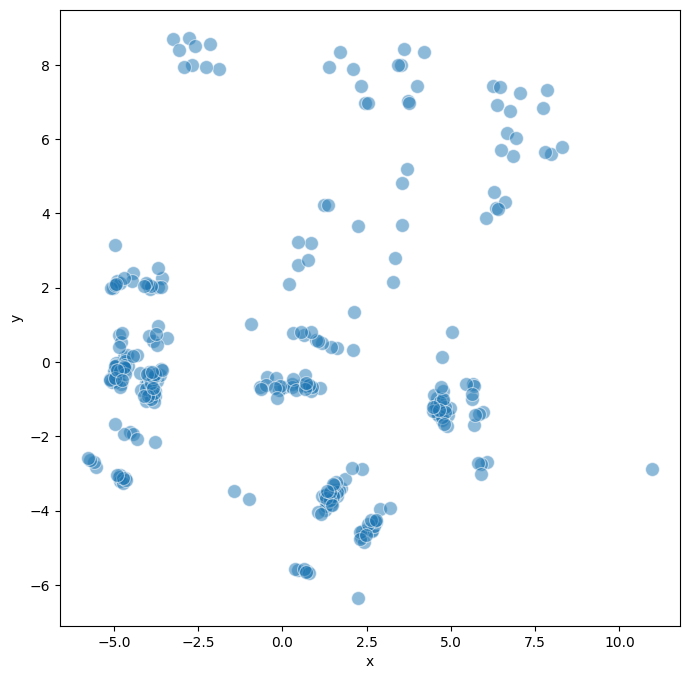

Attractor object created


Processing models:   0%|          | 0/300 [00:00<?, ?it/s]

/home/spankaew/Git/Git_Curie/AstroLogics/src/astrologics/model_attractors.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.attractors_df = model_logic.fillna(0)


Attractors calculation completed


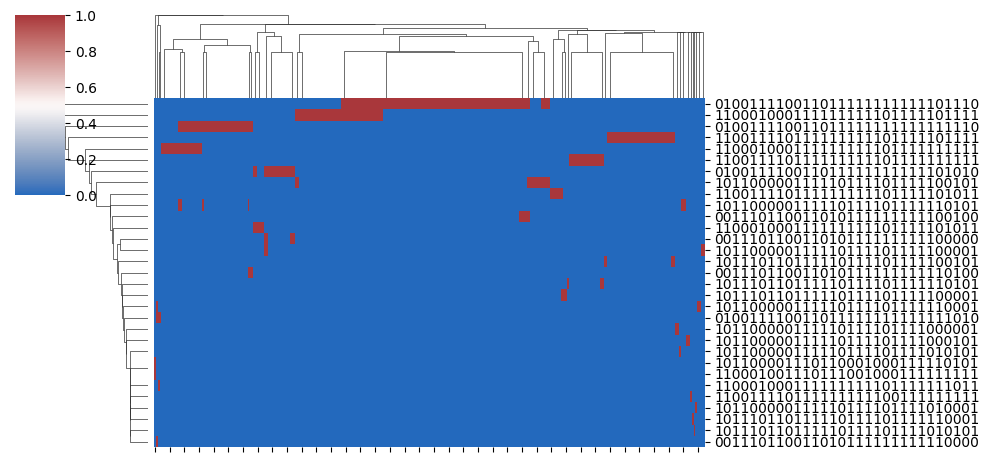

In [18]:
# Load the model path and create LogicEnsemble object
model = ast.ensemble(model_path + 'test_no_constraints/', project_name = 'test_no_constraints')
model.create_simulation()

# Configure simulation parameters
model.simulation.update_parameters(max_time = 15, sample_count = 100, thread_count = 15)
model.simulation.run_simulation()

# Calculate the distance matrix based on the trajectory
model.create_trajectory()
model.trajectory.calculate_distancematrix(mode = 'trajectory')

# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

# Plot the attractor heatmap using seaborn
model.create_attractor()
model.attractor.get_attractors(num_cores=15)
g = sns.clustermap(model.attractor.attractors_df, vmax=1, vmin=0, cmap='vlag')
g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.tick_params(labelbottom=False)

Simulation object created
Start simulation


  0%|          | 0/300 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/300 [00:00<?, ?it/s]

Distance matrix calculated successfully.


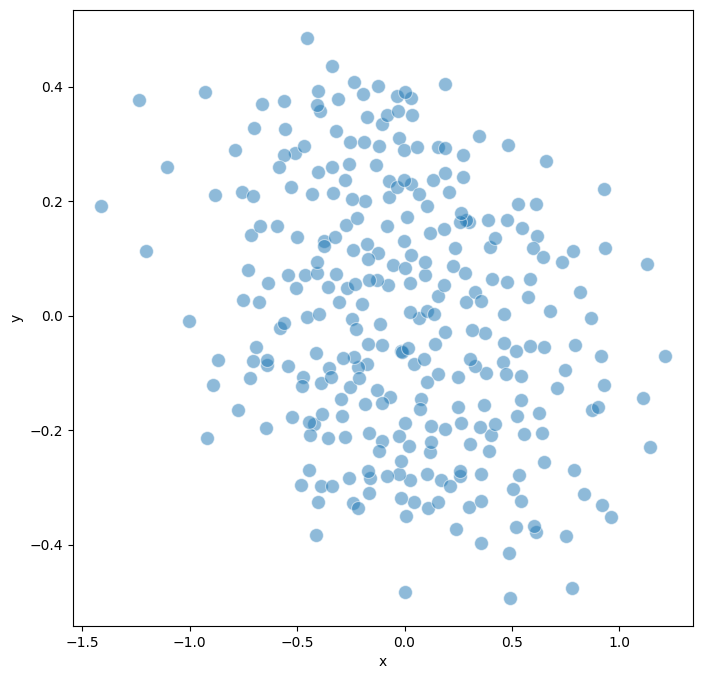

Attractor object created


Processing models:   0%|          | 0/300 [00:00<?, ?it/s]

/home/spankaew/Git/Git_Curie/AstroLogics/src/astrologics/model_attractors.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.attractors_df = model_logic.fillna(0)


Attractors calculation completed


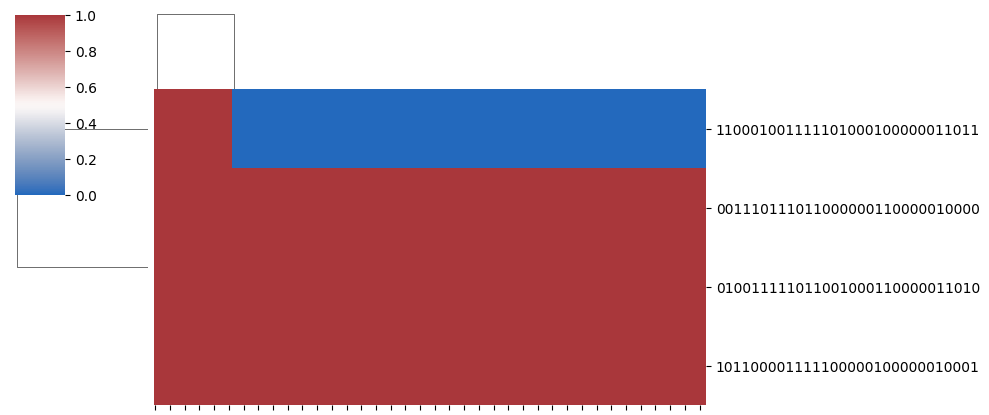

In [19]:
# Load the model path and create LogicEnsemble object
model = ast.ensemble(model_path + 'test_fixedpoints_included/', project_name = 'test_fixedpoints_included')
model.create_simulation()

# Configure simulation parameters
model.simulation.update_parameters(max_time = 15, sample_count = 100, thread_count = 15)
model.simulation.run_simulation()

# Calculate the distance matrix based on the trajectory
model.create_trajectory()
model.trajectory.calculate_distancematrix(mode = 'trajectory')

# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))
# Plot the attractor heatmap using seaborn
model.create_attractor()
model.attractor.get_attractors(num_cores=15)
g = sns.clustermap(model.attractor.attractors_df, vmax=1, vmin=0, cmap='vlag')
g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.tick_params(labelbottom=False)

Simulation object created
Start simulation


  0%|          | 0/300 [00:00<?, ?it/s]

Simulation completed
Trajectory object created
Calculating distance matrix for whole trajectory...


  0%|          | 0/300 [00:00<?, ?it/s]

Distance matrix calculated successfully.


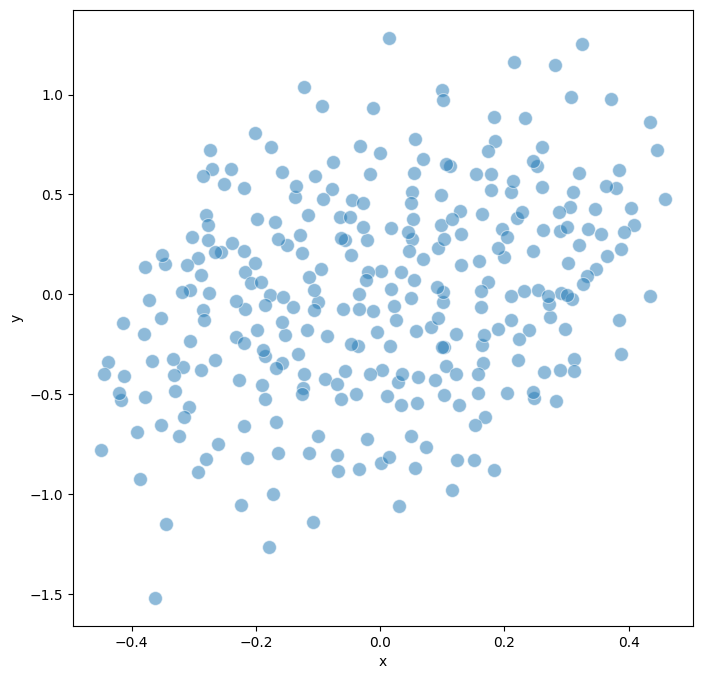

Attractor object created


Processing models:   0%|          | 0/300 [00:00<?, ?it/s]

/home/spankaew/Git/Git_Curie/AstroLogics/src/astrologics/model_attractors.py:81: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.attractors_df = model_logic.fillna(0)
/home/spankaew/anaconda3/envs/astrologics/lib/python3.12/site-packages/seaborn/matrix.py:615: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, max_dependent_coord * 1.05)
/home/spankaew/anaconda3/envs/astrologics/lib/python3.12/site-packages/seaborn/matrix.py:623: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max_dependent_coord * 1.05)


Attractors calculation completed


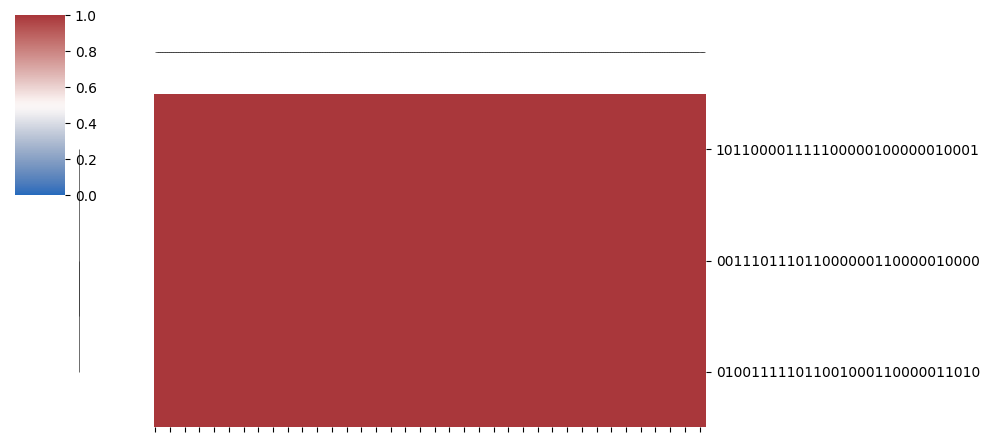

In [20]:
# Load the model path and create LogicEnsemble object
model = ast.ensemble(model_path + 'test_fixedpoints_same/', project_name = 'test_fixedpoints_same')
model.create_simulation()

# Configure simulation parameters
model.simulation.update_parameters(max_time = 15, sample_count = 100, thread_count = 15)
model.simulation.run_simulation()

# Calculate the distance matrix based on the trajectory
model.create_trajectory()
model.trajectory.calculate_distancematrix(mode = 'trajectory')

# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS()
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

# Plot the attractor heatmap using seaborn
model.create_attractor()
model.attractor.get_attractors(num_cores=15)
g = sns.clustermap(model.attractor.attractors_df, vmax=1, vmin=0, cmap='vlag')
g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.tick_params(labelbottom=False)